In [5]:
#import necessary libraries
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GroupKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, accuracy_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier
 
os.makedirs('outputs',exist_ok=True)
os.makedirs('models', exist_ok=True)
 

In [7]:
# Load Master Features

df = pd.read_csv('../data/processed/master_features.csv')

In [9]:
# Define Features and Target

FEATURE_COLS = ['elevation', 'slope', 'aspect', 'curvature','NDVI', 'rainfall', 'competency_index', 'FS']
 
BASELINE_COLS = ['elevation', 'slope', 'aspect', 'curvature','NDVI', 'rainfall']
# Baseline uses only surface features — no competency, no FS
# This is our comparison model to prove subsurface data adds value
 
X_full = df[FEATURE_COLS]
X_baseline = df[BASELINE_COLS]
y  = df['label']
 
print("Full feature set :", FEATURE_COLS)
print("Baseline feature set:", BASELINE_COLS)

print("X_full shape :", X_full.shape)
print("X_baseline shape:", X_baseline.shape)
print("y shape:", y.shape)

print("Class balance:")
print(f" Label 0 (stable) : {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f" Label 1 (landslide) : {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")

Full feature set : ['elevation', 'slope', 'aspect', 'curvature', 'NDVI', 'rainfall', 'competency_index', 'FS']
Baseline feature set: ['elevation', 'slope', 'aspect', 'curvature', 'NDVI', 'rainfall']
X_full shape : (242, 8)
X_baseline shape: (242, 6)
y shape: (242,)
Class balance:
 Label 0 (stable) : 121 (50.0%)
 Label 1 (landslide) : 121 (50.0%)


In [16]:
 # Train Test Split

# Stratified split ensures both classes are proportionally
# represented in both train and test sets
 
X_train_f, X_test_f, y_train, y_test = train_test_split(X_full, y,test_size=0.2,stratify=y,random_state=42)
 
X_train_b, X_test_b, _, _ = train_test_split( X_baseline, y,test_size=0.2, stratify=y,
                                              random_state=42  # same seed so same split as full model)
                                            )
print(f"Training samples : {len(X_train_f)}")
print(f"Test samples : {len(X_test_f)}")

print("Train label distribution:")
print(y_train.value_counts())

print("Test label distribution:")
print(y_test.value_counts())

Training samples : 193
Test samples : 49
Train label distribution:
label
1    97
0    96
Name: count, dtype: int64
Test label distribution:
label
0    25
1    24
Name: count, dtype: int64


In [18]:
 # Train Random Forest (Full Features)

 
rf_full = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',  # handles class imbalance automatically
    random_state=42,
    n_jobs=-1
)
rf_full.fit(X_train_f, y_train)
 
y_pred_rf = rf_full.predict(X_test_f)
y_proba_rf= rf_full.predict_proba(X_test_f)[:, 1]
 
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_proba_rf)
print(f" Accuracy : {rf_acc:.4f}")
print(f" F1 Score : {rf_f1:.4f}")
print(f" ROC-AUC : {rf_auc:.4f}")

print(classification_report(y_test, y_pred_rf, target_names=['Stable (0)', 'Landslide (1)']))

 Accuracy : 0.6531
 F1 Score : 0.6792
 ROC-AUC : 0.7900
               precision    recall  f1-score   support

   Stable (0)       0.70      0.56      0.62        25
Landslide (1)       0.62      0.75      0.68        24

     accuracy                           0.65        49
    macro avg       0.66      0.66      0.65        49
 weighted avg       0.66      0.65      0.65        49



In [19]:
# Train XGBoost (Full Features)

# Calculate scale_pos_weight for class imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count
 
xgb_full = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_full.fit(X_train_f, y_train)
 
y_pred_xgb = xgb_full.predict(X_test_f)
y_proba_xgb = xgb_full.predict_proba(X_test_f)[:, 1]
 
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_proba_xgb)

print(f" Accuracy : {xgb_acc:.4f}")
print(f" F1 Score : {xgb_f1:.4f}")
print(f" ROC-AUC : {xgb_auc:.4f}")

print(classification_report(y_test, y_pred_xgb, target_names=['Stable (0)', 'Landslide (1)']))



 Accuracy : 0.6939
 F1 Score : 0.7059
 ROC-AUC : 0.7750
               precision    recall  f1-score   support

   Stable (0)       0.73      0.64      0.68        25
Landslide (1)       0.67      0.75      0.71        24

     accuracy                           0.69        49
    macro avg       0.70      0.70      0.69        49
 weighted avg       0.70      0.69      0.69        49



In [20]:
# Train Baseline Models (Surface Features Only)


# Baseline Random Forest
rf_base = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train_b, y_train)
y_pred_rf_base = rf_base.predict(X_test_b)
y_proba_rf_base = rf_base.predict_proba(X_test_b)[:, 1]
 
# Baseline XGBoost
xgb_base = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_base.fit(X_train_b, y_train)
y_pred_xgb_base = xgb_base.predict(X_test_b)
y_proba_xgb_base = xgb_base.predict_proba(X_test_b)[:, 1]


print(f"{'Model':<30} {'Accuracy':>10} {'F1 Score':>10} {'ROC-AUC':>10}")
print("-" * 62)
print(f"{'RF — Baseline (surface only)':<30} {accuracy_score(y_test, y_pred_rf_base):>10.4f} {f1_score(y_test, y_pred_rf_base):>10.4f} {roc_auc_score(y_test, y_proba_rf_base):>10.4f}")
print(f"{'RF — Full (surface+subsurface)':<30} {rf_acc:>10.4f} {rf_f1:>10.4f} {rf_auc:>10.4f}")
print(f"{'XGB — Baseline (surface only)':<30} {accuracy_score(y_test, y_pred_xgb_base):>10.4f} {f1_score(y_test, y_pred_xgb_base):>10.4f} {roc_auc_score(y_test, y_proba_xgb_base):>10.4f}")
print(f"{'XGB — Full (surface+subsurface)':<30} {xgb_acc:>10.4f} {xgb_f1:>10.4f} {xgb_auc:>10.4f}")


=== MODEL COMPARISON TABLE ===
Model                            Accuracy   F1 Score    ROC-AUC
--------------------------------------------------------------
RF — Baseline (surface only)       0.6939     0.7170     0.8133
RF — Full (surface+subsurface)     0.6531     0.6792     0.7900
XGB — Baseline (surface only)      0.6735     0.7037     0.7550
XGB — Full (surface+subsurface)     0.6939     0.7059     0.7750


In [29]:
 # Pick the Best Model

# Compare all 4 models on ROC-AUC and pick the best
models = {
    'RF Baseline' : (rf_base,  y_proba_rf_base,  y_pred_rf_base,  roc_auc_score(y_test, y_proba_rf_base)),
    'RF Full' : (rf_full,  y_proba_rf, y_pred_rf, rf_auc),
    'XGB Baseline': (xgb_base, y_proba_xgb_base,  y_pred_xgb_base, roc_auc_score(y_test, y_proba_xgb_base)),
    'XGB Full': (xgb_full, y_proba_xgb, y_pred_xgb, xgb_auc),
}
 
best_name = max(models, key=lambda k: models[k][3])
best_model, best_proba, best_pred, best_auc = models[best_name]
 
print(f"Best model: {best_name} with ROC-AUC = {best_auc:.4f}")


# For the feature importance and susceptibility map we use the best FULL model specifically (not baseline) because we want to use all 8 features including subsurface
 
if 'Full' in best_name:
    final_model= best_model
    final_proba = best_proba
    final_pred= best_pred
    final_X_test = X_test_f
    print(f"Using {best_name} as final model")
else:
    # baseline beats full model,but still used XGB full for the project  to evaluate the contribution of subsurface and physics-based features
    final_model = xgb_full
    final_proba = y_proba_xgb
    final_pred = y_pred_xgb
    final_X_test = X_test_f
    print("Note: Baseline outperformed full model on this split.")
    print("Although the baseline model achieved higher ROC-AUC, the full model is retained to evaluate the contribution of subsurface and physics-based features.")

Best model: RF Baseline with ROC-AUC = 0.8133
Note: Baseline outperformed full model on this split.
Although the baseline model achieved higher ROC-AUC, the full model is retained to evaluate the contribution of subsurface and physics-based features.


In [27]:
 # Spatial Block Cross Validation

# Standard random k-fold would allow nearby points to leak between
# train and test sets. Spatial block CV prevents this by ensuring
# geographically separate blocks are used for train and test.

# Assign each point to a spatial block (~5km grid cells)
df['spatial_block'] = ((df['lat'] / 0.05).astype(int).astype(str) + "_" + (df['lon'] / 0.05).astype(int).astype(str))
 
unique_blocks = df['spatial_block'].nunique()
print(f"Number of spatial blocks : {unique_blocks}")
print(f"Points per block (avg) : {len(df)/unique_blocks:.1f}")
 
# Use 3-fold if fewer than 150 samples, else 5-fold
n_splits = 3 if len(df) < 150 else 5
gkf = GroupKFold(n_splits=n_splits)
 
print(f"Using {n_splits}-fold spatial cross validation")
print()
 
cv_scores_auc = []
cv_scores_f1 = []
 
for fold, (train_idx, test_idx) in enumerate( gkf.split(X_full, y, groups=df['spatial_block'])):
 
    X_cv_train = X_full.iloc[train_idx]
    X_cv_test = X_full.iloc[test_idx]
    y_cv_train = y.iloc[train_idx]
    y_cv_test = y.iloc[test_idx]
 
    # Use same model type as best full model
    cv_model = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        scale_pos_weight=scale_weight, random_state=42,
        eval_metric='logloss', verbosity=0
    )
    cv_model.fit(X_cv_train, y_cv_train)
 
    cv_proba = cv_model.predict_proba(X_cv_test)[:, 1]
    cv_pred = cv_model.predict(X_cv_test)
 
    fold_auc = roc_auc_score(y_cv_test, cv_proba)
    fold_f1 = f1_score(y_cv_test, cv_pred)
 
    cv_scores_auc.append(fold_auc)
    cv_scores_f1.append(fold_f1)
    print(f"Fold {fold+1}: ROC-AUC = {fold_auc:.4f}, F1 = {fold_f1:.4f}")

print(f"Spatial CV ROC-AUC : {np.mean(cv_scores_auc):.4f} ± {np.std(cv_scores_auc):.4f}")
print(f"Spatial CV F1 : {np.mean(cv_scores_f1):.4f} ± {np.std(cv_scores_f1):.4f}")
   

Number of spatial blocks : 181
Points per block (avg) : 1.3
Using 5-fold spatial cross validation

Fold 1: ROC-AUC = 0.8294, F1 = 0.7667
Fold 2: ROC-AUC = 0.5667, F1 = 0.5283
Fold 3: ROC-AUC = 0.5335, F1 = 0.2857
Fold 4: ROC-AUC = 0.7518, F1 = 0.6190
Fold 5: ROC-AUC = 0.6337, F1 = 0.5417
Spatial CV ROC-AUC : 0.6630 ± 0.1118
Spatial CV F1 : 0.5483 ± 0.1563


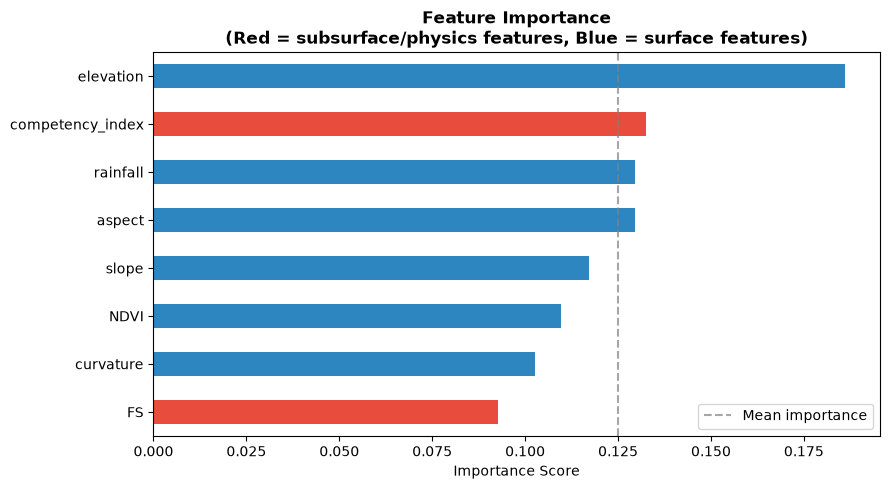

Top 3 most important features:
elevation           0.186167
competency_index    0.132565
rainfall            0.129515
dtype: float32


In [31]:
# Feature Importance Plot

if hasattr(final_model, 'feature_importances_'):
    feature_names = FEATURE_COLS if len(final_model.feature_importances_) == len(FEATURE_COLS) else BASELINE_COLS
    importances = pd.Series(final_model.feature_importances_,index=feature_names).sort_values(ascending=True)
 
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = ['#E74C3C' if i in ['competency_index', 'FS']
              else '#2E86C1' for i in importances.index]
    importances.plot(kind='barh', ax=ax, color=colors)
 
    ax.set_title('Feature Importance\n' '(Red = subsurface/physics features, Blue = surface features)',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.axvline(x=importances.mean(), color='gray',linestyle='--', alpha=0.7, label='Mean importance')
    ax.legend()
    plt.tight_layout()
    plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
 
    print("Top 3 most important features:")
    print(importances.sort_values(ascending=False).head(3))
 

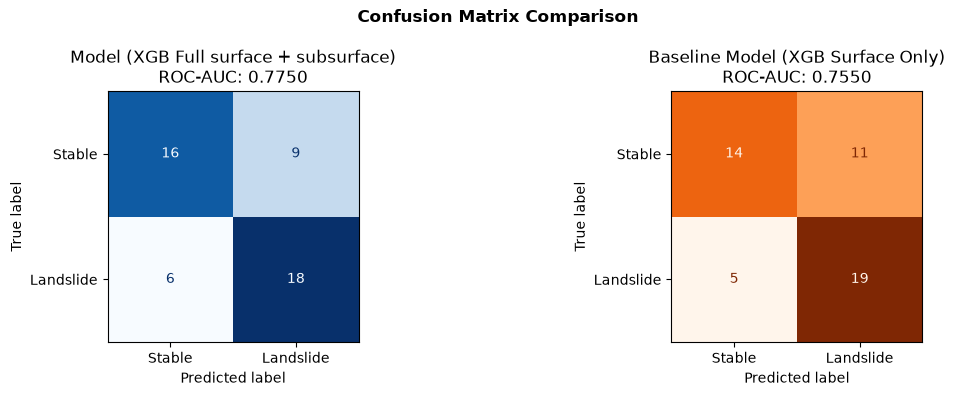

In [34]:
 # Confusion Matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Full model confusion matrix
cm_full = confusion_matrix(y_test, final_pred)
disp1 = ConfusionMatrixDisplay( confusion_matrix=cm_full,display_labels=['Stable', 'Landslide'])
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Model (XGB Full surface + subsurface)\nROC-AUC: {xgb_auc:.4f}')
 
# Baseline confusion matrix (for comparison)
cm_base = confusion_matrix(y_test, y_pred_xgb_base)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_base,display_labels=['Stable', 'Landslide'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'Baseline Model (XGB Surface Only)\n' f'ROC-AUC: {roc_auc_score(y_test, y_proba_xgb_base):.4f}')
 
plt.suptitle(' Confusion Matrix Comparison', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

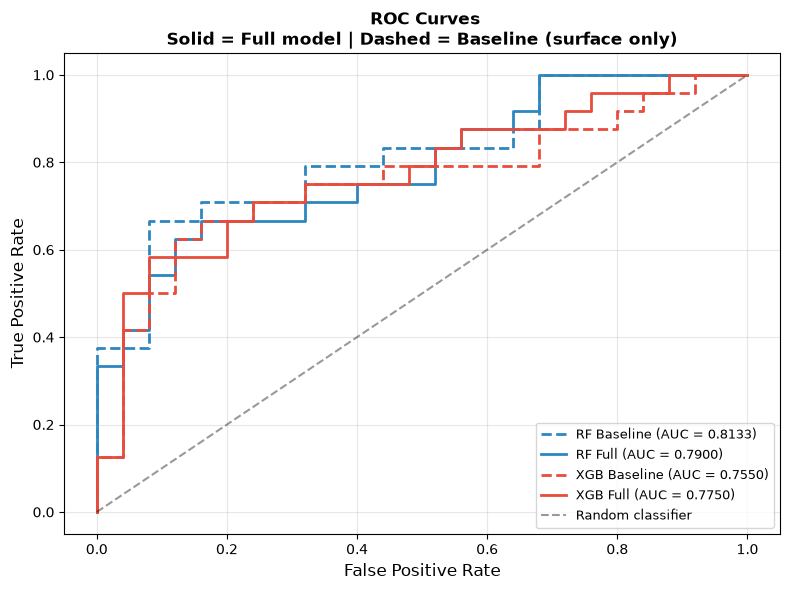

In [35]:
# ROC Curves (All Models)

fig, ax = plt.subplots(figsize=(8, 6))
 
# Plot all 4 ROC curves
for name, (_, proba, _, _) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    linestyle = '-' if 'Full' in name else '--'
    color = '#E74C3C' if 'XGB' in name else '#2E86C1'
    ax.plot(fpr, tpr, linestyle=linestyle, color=color,label=f'{name} (AUC = {auc_val:.4f})', linewidth=2)
 
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(' ROC Curves\n''Solid = Full model | Dashed = Baseline (surface only)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# Save Final Model

joblib.dump(final_model, 'models/final_model.pkl')
joblib.dump(FEATURE_COLS, 'models/feature_cols.pkl')

# Also save baseline for reference
joblib.dump(xgb_base, 'models/baseline_model.pkl')


['models/baseline_model.pkl']